RQ1 - F1 - Three Testing Groups as Instru testing adopters

In [3]:
# RQ1 - F1 - Three Testing Groups as Instru testing adopters (revised per spec)
# -*- coding: utf-8 -*-
"""
####
Fully_CI_Automated: Adopters == True and execution_environment not blank and test_invocation not blank and instru_t_signal_config == True.

Gradle_Only_Configured: Adopters == True and only instru_t_signal_config == True (both execution_environment and test_invocation are blank).

Partially_CI_Configured: Adopters == True but not in the two cases above.

Other: Adopters == False.

#####
"""
from pathlib import Path
import pandas as pd

# ---------- CONFIG ----------
CSV_PATH = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\5.0_Total_Repo.csv"
# Alternative for this environment:
# CSV_PATH = r"/mnt/data/5.0_Total_Repo.csv"

# ---------- helpers ----------
def to01(s: pd.Series) -> pd.Series:
    """Coerce to 0/1 from bool/numeric/string tokens."""
    if s.dtype == bool:
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return (pd.to_numeric(s, errors="coerce").fillna(0) > 0).astype(int)
    t = s.astype(str).str.strip().str.lower()
    token_map = {
        "1":1, "true":1, "yes":1, "y":1, "t":1, "on":1, "adopter":1,
        "0":0, "false":0, "no":0, "n":0, "f":0, "off":0, "":0,
        "none":0, "null":0, "na":0, "nan":0, "unknown":0
    }
    mapped = t.map(token_map)
    num = pd.to_numeric(t.str.replace(r"[^0-9\.\-]+","",regex=True), errors="coerce")
    num01 = (num.fillna(0) > 0).astype(int)
    return mapped.where(mapped.notna(), num01).fillna(0).astype(int)

def pick_col(df: pd.DataFrame, candidates) -> str | None:
    cols = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in cols:
            return cols[c.lower()]
    return None

def is_nonblank_series(s: pd.Series) -> pd.Series:
    """True if cell has a meaningful non-blank value."""
    if s is None:
        return pd.Series(False, index=s.index if hasattr(s, "index") else None)
    t = s.astype(str).str.strip().str.lower()
    blanks = {"", "nan", "none", "null", "na", "unknown"}
    return ~t.isin(blanks)

# ---------- load ----------
csv_path = Path(CSV_PATH)
df = pd.read_csv(csv_path, encoding="utf-8-sig")

# ---------- required columns ----------
col_b  = pick_col(df, ["instru_t_signal_config"])
col_env = pick_col(df, ["execution_environment"])
col_inv = pick_col(df, ["test_invocation"])
if not all([col_b, col_env, col_inv]):
    missing = [name for name, col in [("instru_t_signal_config", col_b),
                                      ("execution_environment", col_env),
                                      ("test_invocation", col_inv)] if not col]
    raise KeyError(f"Missing required column(s): {missing}")

# ---------- adopters flag ----------
adopt_col = pick_col(df, ["Adopters", "Adopters_int", "Adopted_Primary", "adopted_primary", "is_adopter"])
if adopt_col is not None:
    ADOPT = to01(df[adopt_col])
else:
    # Derive: Adopters := Instru_test == 1 AND (instru_t_signal_config == 1 OR ci_android_signal == 1)
    col_at  = pick_col(df, ["Instru_test"])
    if not col_at:
        raise KeyError("Missing required column: Instru_test (to derive Adopters).")
    AT = to01(df[col_at])
    B  = to01(df[col_b])
    col_ci = pick_col(df, ["ci_android_signal"])
    if col_ci:
        Y = to01(df[col_ci])
    else:
        Y = pd.Series(0, index=df.index)
    ADOPT = (AT.eq(1) & (B.eq(1) | Y.eq(1))).astype(int)

# ---------- presence flags (not blank) ----------
B = to01(df[col_b])
E_present = is_nonblank_series(df[col_env])
T_present = is_nonblank_series(df[col_inv])

# ---------- subgroup labeling ----------
labels = pd.Series("Other", index=df.index)

# Within adopters:
is_adopter = ADOPT.eq(1)

# Fully_CI_Automated: adopters AND E & T not blank AND B == 1
fully = is_adopter & E_present & T_present & B.eq(1)

# Gradle_Only_Configured: adopters AND only B == 1 (E and T blank)
gradle_only = is_adopter & B.eq(1) & (~E_present) & (~T_present)

# Partially_CI_Configured: adopters but not fully/gradle_only
partial = is_adopter & (~fully) & (~gradle_only)

labels[fully] = "Fully_CI_Automated"
labels[gradle_only] = "Gradle_Only_Configured"
labels[partial] = "Partially_CI_Configured"

# ---------- summaries ----------
order_adopters = ["Gradle_Only_Configured", "Partially_CI_Configured", "Fully_CI_Automated"]
order_all = order_adopters + ["Other"]

mask_adopters = is_adopter
N_adopters = int(mask_adopters.sum())
N_total = int(len(df))

# Adopters-only summary
sub_adopters = labels.where(mask_adopters)
counts_adopters = sub_adopters.value_counts().reindex(order_adopters).fillna(0).astype(int)
rates_adopters = (counts_adopters / max(N_adopters, 1) * 100).round(1)

summary_adopters = pd.DataFrame({
    "Testing Practice": order_adopters,
    "Count": [int(counts_adopters.get(k, 0)) for k in order_adopters],
    "Rate (% of adopters)": [float(rates_adopters.get(k, 0.0)) for k in order_adopters],
})

# All repos summary (includes 'Other')
counts_all = labels.value_counts().reindex(order_all).fillna(0).astype(int)
rates_all = (counts_all / max(N_total, 1) * 100).round(1)

summary_all = pd.DataFrame({
    "Testing Practice": order_all,
    "Count": [int(counts_all.get(k, 0)) for k in order_all],
    "Rate (% of all repos)": [float(rates_all.get(k, 0.0)) for k in order_all],
})

# ---------- outputs ----------
print(f"\nTotal repositories: {N_total}")
print(f"Total adopters:     {N_adopters}\n")

print("Adopter subgroups (within adopters):")
print(summary_adopters.to_string(index=False))

print("\nAll repositories (including 'Other'):")
print(summary_all.to_string(index=False))

# Save CSVs
out1 = csv_path.with_name("adopter_subgroups_summary.csv")
out2 = csv_path.with_name("adopter_subgroups_summary_all.csv")
summary_adopters.to_csv(out1, index=False, encoding="utf-8-sig")
summary_all.to_csv(out2, index=False, encoding="utf-8-sig")
print(f"\n[OK] Saved: {out1}")
print(f"[OK] Saved: {out2}")



Total repositories: 4518
Total adopters:     1548

Adopter subgroups (within adopters):
       Testing Practice  Count  Rate (% of adopters)
 Gradle_Only_Configured   1173                  75.8
Partially_CI_Configured    135                   8.7
     Fully_CI_Automated    240                  15.5

All repositories (including 'Other'):
       Testing Practice  Count  Rate (% of all repos)
 Gradle_Only_Configured   1173                   26.0
Partially_CI_Configured    135                    3.0
     Fully_CI_Automated    240                    5.3
                  Other   2970                   65.7

[OK] Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\adopter_subgroups_summary.csv
[OK] Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\adopter_subgroups_summary_all.csv


Loaded: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\5.0_Total_Repo.csv
Adopters vs Non-adopters: 1548 / 2970

stargazers_count summary:
  Adopters     n=1548  median=204.00  IQR=(93.00, 629.00)
  Non-adopters n=2970  median=226.00  IQR=(101.00, 664.50)

repo_age (years) summary:
  Adopters     n=1548  median=5.80  IQR=(3.59, 8.38)
  Non-adopters n=2970  median=5.68  IQR=(3.33, 8.74)

contributors summary:
  Adopters     n=1548  median=5.00  IQR=(2.00, 16.00)
  Non-adopters n=2970  median=5.00  IQR=(2.00, 16.00)

pull_requests summary:
  Adopters     n=1548  median=27.00  IQR=(5.00, 178.00)
  Non-adopters n=2970  median=26.00  IQR=(5.00, 110.00)

size summary:
  Adopters     n=1548  median=10803.50  IQR=(2602.00, 47856.50)
  Non-adopters n=2970  median=9797.50  IQR=(2081.00, 40664.25)

forks_count summary:
  Adopters     n=1548  median=34.00  IQR=(15.00, 106.00)
  Non-adopters n=2970  median=40.00  IQR=(17.00, 107.00)

commits_GitAPI summary:
  Ad

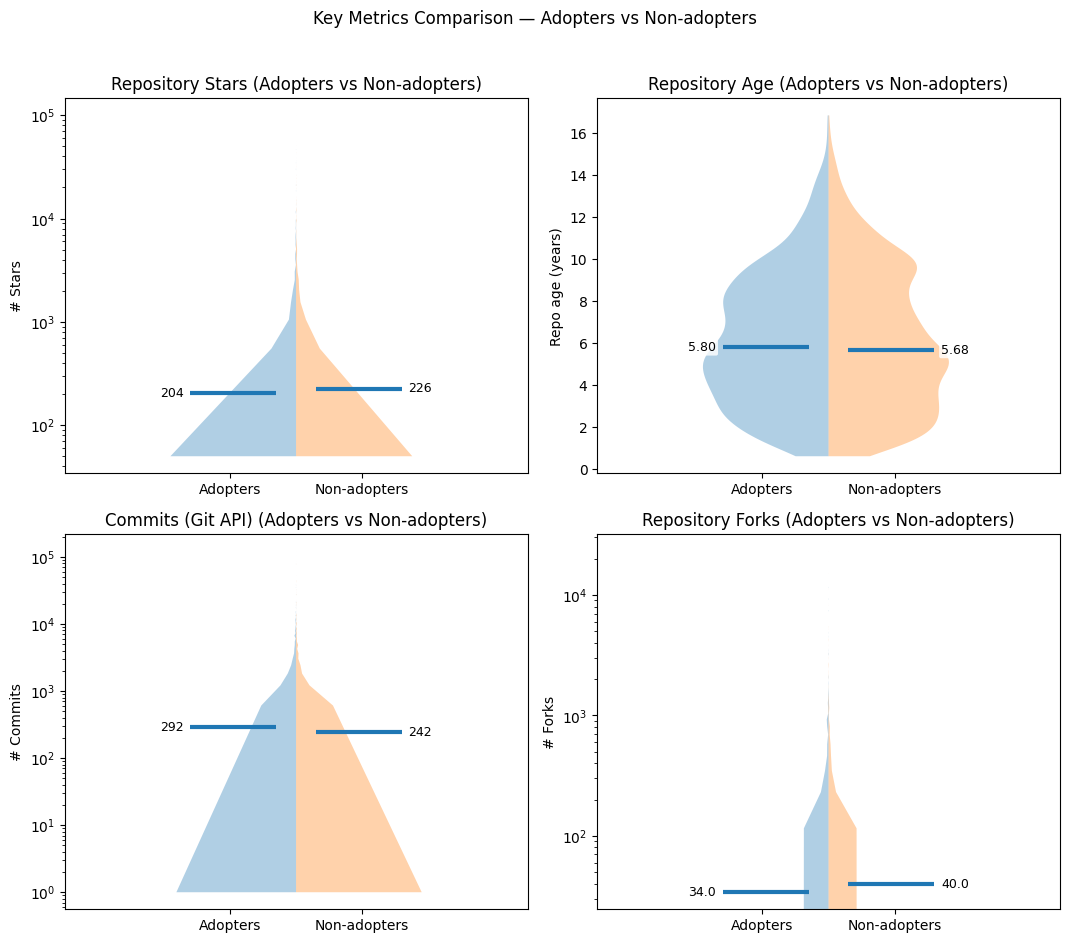


Saved figure: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\one_figure_beansplots_adoption_core_raw.png


In [4]:
# RQ1 - F2 - Adopters vs Non-adopters - Core Raw Metrics
# -*- coding: utf-8 -*-
"""
Adopters vs Non-adopters — core raw metrics only

Plots (2x2):
  1) Stars (log)
  2) Repo age (years, linear)
  3) Commits (Git API, log)
  4) Forks (log)

Also writes 'adoption_metric_summaries.csv' with medians/IQRs for
all computed metrics (raw + a few derived), but derived metrics are NOT plotted.

Inputs (first existing is used):
  C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\{5.0_Total_Repo.csv,...}

Output figure:
  one_figure_beansplots_adoption_core_raw.png
"""

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
DATA_DIR = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet")
PREFERRED_FILES = [
    "5.0_Total_Repo.csv",
    "3.2_Total_Repo_MR.csv",
    "3.2_Total_Repo.csv",
    "Total_Repo_MR.csv",
    "Total_Repo.csv",
]

STYLE = "beans"
HIDE_OUTLIERS = True

# Adoption flag candidates; coerced to 0/1 (prefers 'Adopters')
ADOPTION_CANDIDATES = ["Adopters", "Adopters_int", "Adopted_Primary", "adopted_primary", "is_adopter"]

# Metric synonyms (first match wins)
METRIC_SYNONYMS = {
    "stargazers_count": ["stargazers_count", "stars"],
    "repo_age": ["repo_age", "age_years", "project_age_years", "age", "age_yrs"],
    "contributors": ["contributors", "num_contributors", "contributors_total"],
    "pull_requests": ["pull_requests", "prs", "total_prs", "prs_total"],
    "size": ["size", "code_size", "loc", "repo_size"],
    "forks_count": ["forks_count", "forks"],
    "commits_GitAPI": ["commits_GitAPI", "commits", "local_commit_count", "total_commits"],
}

# ------------- helpers -------------
def choose_dataset_path(root: Path) -> Path:
    for name in PREFERRED_FILES:
        p = root / name
        if p.exists():
            return p
    csvs = sorted(root.glob("*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not csvs:
        raise FileNotFoundError(f"No CSV files found in {root}")
    return csvs[0]

def pick_col(frame: pd.DataFrame, candidates) -> str | None:
    lc = {c.lower(): c for c in frame.columns}
    for cand in candidates:
        if cand.lower() in lc:
            return lc[cand.lower()]
    return None

def to_01(series: pd.Series) -> pd.Series:
    s = series
    if s.dtype == bool:
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return (pd.to_numeric(s, errors="coerce").fillna(0) > 0).astype(int)
    t = s.astype(str).str.strip().str.lower()
    token_map = {
        "1":1,"true":1,"yes":1,"y":1,"t":1,"on":1,"adopter":1,
        "0":0,"false":0,"no":0,"n":0,"f":0,"off":0,"":0,
        "none":0,"null":0,"na":0,"nan":0
    }
    mapped = t.map(token_map)
    num = pd.to_numeric(t.str.replace(r"[^0-9\.\-]+", "", regex=True), errors="coerce")
    num01 = (num.fillna(0) > 0).astype(int)
    return mapped.where(mapped.notna(), num01).fillna(0).astype(int)

def to_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False), errors="coerce")

def summarize(name, s_adopters, s_nonadopters) -> dict:
    def stats(x):
        x = x.dropna().values
        if x.size == 0:
            return {"n": 0, "median": np.nan, "p25": np.nan, "p75": np.nan}
        return {
            "n": x.size,
            "median": float(np.nanmedian(x)),
            "p25": float(np.nanpercentile(x, 25)),
            "p75": float(np.nanpercentile(x, 75)),
        }
    st, s0 = stats(s_adopters), stats(s_nonadopters)
    print(f"\n{name} summary:")
    print(f"  Adopters     n={st['n']:<5} median={st['median']:.2f}  IQR=({st['p25']:.2f}, {st['p75']:.2f})")
    print(f"  Non-adopters n={s0['n']:<5} median={s0['median']:.2f}  IQR=({s0['p25']:.2f}, {s0['p75']:.2f})")
    return {
        "metric": name,
        **{f"adopters_{k}": v for k, v in st.items()},
        **{f"nonadopters_{k}": v for k, v in s0.items()},
    }

def human_title_and_ylabel(m: str):
    ml = m.lower()
    if ml in ("repo_age", "age_years", "project_age_years", "age", "age_yrs", "repo_age (years)"):
        return "Repository Age (Adopters vs Non-adopters)", "Repo age (years)"
    if ml in ("stargazers_count", "stars"):
        return "Repository Stars (Adopters vs Non-adopters)", "# Stars"
    if ml in ("forks_count", "forks"):
        return "Repository Forks (Adopters vs Non-adopters)", "# Forks"
    if ml in ("commits_gitapi", "commits", "local_commit_count", "total_commits", "commits_GitAPI".lower()):
        return "Commits (Git API) (Adopters vs Non-adopters)", "# Commits"
    return m, m

# ---- shared KDE for both sides (common grid & bandwidth) ----
def _kde_shared(y1: np.ndarray, y0: np.ndarray, n_points: int = 200):
    z1 = y1[np.isfinite(y1)]
    z0 = y0[np.isfinite(y0)]
    z = np.concatenate([z1, z0])
    if z.size < 2:
        v = z[0] if z.size == 1 else 0.0
        y = np.linspace(v - 1, v + 1, n_points)
        d1 = np.zeros_like(y); d0 = np.zeros_like(y)
        if z.size == 1:
            idx = np.argmin(np.abs(y - v))
            d1[idx] = 1.0
        return y, d1, d0
    y = np.linspace(z.min(), z.max(), n_points)
    std = np.std(z, ddof=1)
    iqr = np.subtract(*np.percentile(z, [75, 25]))
    sigma = min(std, iqr / 1.349) if (std > 0 and iqr > 0) else max(std, iqr, 1e-8)
    h = max(1.06 * sigma * (z.size ** (-1/5)), 1e-8)
    def kde(samples):
        if samples.size == 0:
            return np.zeros_like(y)
        u = (y[:, None] - samples[None, :]) / h
        return np.exp(-0.5 * u**2).sum(axis=1) / (samples.size * h * np.sqrt(2 * np.pi))
    d1 = kde(z1); d0 = kde(z0)
    m = max(d1.max(), d0.max(), 1e-12)
    return y, d1/m, d0/m

# ------------- load -------------
csv_path = choose_dataset_path(DATA_DIR)
df = pd.read_csv(csv_path, encoding="utf-8-sig")
print(f"Loaded: {csv_path}")

# adoption mask
adopt_col = pick_col(df, ADOPTION_CANDIDATES)
if not adopt_col:
    raise KeyError(f"Could not find adoption column. Expected one of: {ADOPTION_CANDIDATES}")
adopt = to_01(df[adopt_col])
mask_adopters, mask_nonadopters = adopt.eq(1), adopt.eq(0)
print("Adopters vs Non-adopters:", int(mask_adopters.sum()), "/", int(mask_nonadopters.sum()))

# resolve source columns
resolved = {}
for canon, syns in METRIC_SYNONYMS.items():
    found = pick_col(df, syns)
    if found:
        resolved[canon] = found

# required for plots
if "stargazers_count" not in resolved:
    raise KeyError("Missing required column: stargazers_count (or a synonym like 'stars').")
if "repo_age" not in resolved:
    raise KeyError("Missing required column: repo_age (or synonyms like 'age_years').")
if "commits_GitAPI" not in resolved and not any(k in resolved for k in ["commits_GitAPI","commits","local_commit_count","total_commits"]):
    raise KeyError("Missing commits column (commits_GitAPI/commits/local_commit_count/total_commits).")
if "forks_count" not in resolved:
    raise KeyError("Missing required column: forks_count (or a synonym like 'forks').")

# prepare numeric series
prepared: dict[str, pd.Series] = {}
for canon, col in resolved.items():
    s = to_num(df[col])
    if canon == "repo_age":
        # convert days->years if needed
        mx = s.dropna().max()
        if pd.notna(mx) and mx > 1000:
            s = s / 365.25
        prepared["repo_age (years)"] = s
    else:
        prepared[col] = s

# keep handles for the four raw metrics we will plot
stars_col   = resolved["stargazers_count"]
age_label   = "repo_age (years)"
# prefer commits_GitAPI if available
commits_col = resolved.get("commits_GitAPI") or resolved.get("commits") or resolved.get("local_commit_count") or resolved.get("total_commits")
forks_col   = resolved["forks_count"]

# which labels to log (only raw counts)
RAW_LOG_LABELS = {stars_col, commits_col, forks_col}

# optional derived series for CSV only (not plotted)
contrib_col = resolved.get("contributors")
prs_col     = resolved.get("pull_requests")
if commits_col in prepared and age_label in prepared:
    prepared["commits_per_year"] = prepared[commits_col] / prepared[age_label].replace(0, np.nan)
if prs_col in prepared and age_label in prepared:
    prepared["prs_per_year"] = prepared[prs_col] / prepared[age_label].replace(0, np.nan)
if contrib_col in prepared and commits_col in prepared:
    prepared["commits_per_contributor"] = prepared[commits_col] / prepared[contrib_col].replace(0, np.nan)
if contrib_col in prepared and prs_col in prepared:
    prepared["prs_per_contributor"] = prepared[prs_col] / prepared[contrib_col].replace(0, np.nan)

# ------------- summaries (CSV) -------------
summary_rows = []
for label, series in prepared.items():
    row = summarize(label, series[mask_adopters], series[mask_nonadopters])
    row["metric_label"] = label
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
summary_out = csv_path.with_name("adoption_metric_summaries.csv")
summary_df.to_csv(summary_out, index=False, encoding="utf-8-sig")
print(f"\nSaved summaries: {summary_out}")

# ------------- plotting (RAW ONLY, 2x2) -------------
plot_fields = [stars_col, age_label, commits_col, forks_col]
titles = {f: human_title_and_ylabel(f)[0] for f in plot_fields}
ylabels = {f: human_title_and_ylabel(f)[1] for f in plot_fields}

n = len(plot_fields)
n_cols, n_rows = 2, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.4 * n_cols, 4.6 * n_rows))
axes = axes.flatten()

def draw_panel(ax, y_adopters, y_nonadopters, label):
    title, y_label = titles[label], ylabels[label]
    y_adopters = pd.Series(y_adopters).dropna().values
    y_nonadopters = pd.Series(y_nonadopters).dropna().values

    def fmt_med(v):
        if np.isnan(v): return "—"
        if abs(v) >= 100: return f"{v:,.0f}"
        if abs(v) >= 10:  return f"{v:,.1f}"
        return f"{v:,.2f}"

    if STYLE.lower() == "beans":
        x0 = 1.5
        max_half_width = 0.38
        y_grid, dA, dN = _kde_shared(y_adopters, y_nonadopters)

        # left bean (Adopters)
        x_left = x0 - dA * max_half_width
        poly_left = np.concatenate([np.c_[x_left, y_grid], np.c_[[x0]*len(y_grid[::-1]), y_grid[::-1]]])
        ax.fill(poly_left[:, 0], poly_left[:, 1], alpha=0.35, linewidth=0)

        # right bean (Non-adopters)
        x_right = x0 + dN * max_half_width
        poly_right = np.concatenate([np.c_[x_right, y_grid], np.c_[[x0]*len(y_grid[::-1]), y_grid[::-1]]])
        ax.fill(poly_right[:, 0], poly_right[:, 1], alpha=0.35, linewidth=0)

        # medians + labels (side-anchored)
        def draw_median(side, data):
            if data.size == 0: return
            med = float(np.median(data))
            if side == "left":
                ax.hlines(med, x0 - 0.32, x0 - 0.06, linewidth=3)
                ax.text(x0 - 0.34, med, fmt_med(med),
                        ha="right", va="center", fontsize=9,
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))
            else:
                ax.hlines(med, x0 + 0.06, x0 + 0.32, linewidth=3)
                ax.text(x0 + 0.34, med, fmt_med(med),
                        ha="left", va="center", fontsize=9,
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))

        draw_median("left",  y_adopters)
        draw_median("right", y_nonadopters)

        ax.set_xticks([x0 - 0.2, x0 + 0.2], ["Adopters", "Non-adopters"])
        ax.set_xlim(x0 - 0.7, x0 + 0.7)

    else:
        ax.boxplot([y_adopters, y_nonadopters], labels=["Adopters", "Non-adopters"], showfliers=not HIDE_OUTLIERS)

    ax.set_title(title)
    ax.set_ylabel(y_label)

    # log only for the raw count panels we selected
    if label in RAW_LOG_LABELS:
        ax.set_yscale("log")

# draw
for ax, label in zip(axes, plot_fields):
    s = prepared[label]
    draw_panel(ax, s[mask_adopters], s[mask_nonadopters], label)

# tidy
for j in range(len(plot_fields), len(axes)):
    axes[j].axis("off")

fig.suptitle("Key Metrics Comparison — Adopters vs Non-adopters", y=1.02)
plt.tight_layout()

out_name = "one_figure_beansplots_adoption_core_raw.png"
out_path = csv_path.with_name(out_name)
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"\nSaved figure: {out_path}")


RQ1 - F3

In [5]:
#RQ1 - F3 - Distribution of primary language among adopters
# -*- coding: utf-8 -*-
"""
Distribution of primary language among adopters
- Share = % of ALL adopters that belong to each language bucket
- Adoption rate in group = % of repos in that language bucket that are adopters
- Group total (n) = total repos in the language bucket

Reads dataset from: D:\1_Main_Spreadsheet  (prefers 5.0_Total_Repo.csv, else newest .csv)
Writes: adoption_distribution_by_language.csv  (to the same folder)
"""

from pathlib import Path
import pandas as pd

# ------------------- CONFIG -------------------
DATA_DIR = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet")
PREFERRED_FILES = ["5.0_Total_Repo.csv"]
ADOPTER_COL_CANDS = ["Adopters", "Adopters_int", "Adopted_Primary", "adopted_primary", "is_adopter"]
LANG_COL_CANDS = ["primary_language", "language", "main_language", "repo_language", "lang"]
OUT_NAME = "adoption_distribution_by_language.csv"
# ------------------------------------------------

def choose_dataset_path(root: Path) -> Path:
    if not root.exists():
        raise FileNotFoundError(f"Data folder not found: {root}")
    for name in PREFERRED_FILES:
        p = root / name
        if p.exists():
            return p
    csvs = sorted(root.glob("*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not csvs:
        raise FileNotFoundError(f"No CSV files found in {root}")
    return csvs[0]

def pick_col(df: pd.DataFrame, candidates) -> str | None:
    lc = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lc:
            return lc[cand.lower()]
    return None

def to_adopter01(s: pd.Series) -> pd.Series:
    """Coerce to 0/1 for adopters."""
    if s.dtype == bool:
        return s.astype(int)
    if pd.api.types.is_numeric_dtype(s):
        return (pd.to_numeric(s, errors="coerce").fillna(0) > 0).astype(int)
    t = s.astype(str).str.strip().str.lower()
    token_map = {
        "1":1,"true":1,"yes":1,"y":1,"t":1,"on":1,"adopter":1,
        "0":0,"false":0,"no":0,"n":0,"f":0,"off":0,"":0,
        "none":0,"null":0,"na":0,"nan":0
    }
    mapped = t.map(token_map)
    num = pd.to_numeric(t.str.replace(r"[^0-9\.\-]+", "", regex=True), errors="coerce")
    num01 = (num.fillna(0) > 0).astype(int)
    return mapped.where(mapped.notna(), num01).fillna(0).astype(int)

def bucket_language(raw: str) -> str:
    """Map raw language names to the requested buckets."""
    if not isinstance(raw, str) or not raw.strip():
        return "Other"
    s = raw.strip().lower()
    # Kotlin
    if "kotlin" in s:
        return "Kotlin"
    # JavaScript / TypeScript
    if "javascript" in s or "typescript" in s or s in {"js","ts"}:
        return "JavaScript/TypeScript"
    # Java (avoid matching JavaScript)
    if s == "java":
        return "Java"
    # Dart
    if "dart" in s:
        return "Dart"
    # C / C++  (exclude C# and Objective-C)
    if s in {"c", "c++", "cpp"} or "c++" in s or s.startswith("cpp"):
        return "C / C++"
    if s == "c#" or "csharp" in s or "c#" in s:
        return "Other"
    if "objective-c" in s or "objective c" in s:
        return "Other"
    # Everything else
    return "Other"

def main():
    csv_path = choose_dataset_path(DATA_DIR)
    df = pd.read_csv(csv_path, encoding="utf-8-sig")
    print(f"Loaded: {csv_path}")

    adopter_col = pick_col(df, ADOPTER_COL_CANDS)
    if not adopter_col:
        raise KeyError(f"Could not find adopter column. Tried: {ADOPTER_COL_CANDS}")

    lang_col = pick_col(df, LANG_COL_CANDS)
    if not lang_col:
        raise KeyError(f"Could not find language column. Tried: {LANG_COL_CANDS}")

    adopters01 = to_adopter01(df[adopter_col])
    lang_bucket = df[lang_col].map(bucket_language)

    # Totals per bucket (all repos)
    group_total = lang_bucket.value_counts(dropna=False).rename("Group total (n)")

    # Adopters per bucket
    adopters = (adopters01 == 1)
    adopters_per_bucket = lang_bucket[adopters].value_counts().rename("Adopters (n)")

    # Align indexes
    idx = group_total.index
    adopters_per_bucket = adopters_per_bucket.reindex(idx, fill_value=0)

    total_adopters = int(adopters_per_bucket.sum())
    total_repos = int(group_total.sum())

    # Compute shares and rates
    share_all_adopters = (adopters_per_bucket / total_adopters * 100).round(0).astype("Int64")  # %
    adoption_rate_in_group = (adopters_per_bucket / group_total * 100).round(0).astype("Int64")  # %

    out_df = pd.DataFrame({
        "Language": idx,
        "Adopters (n)": adopters_per_bucket.values.astype(int),
        "Share of all adopters (%)": share_all_adopters.values,
        "Adoption rate in group (%)": adoption_rate_in_group.values,
        "Group total (n)": group_total.values.astype(int),
    })

    # Sort by adopters desc, put common buckets first if present
    preferred_order = ["Kotlin", "Java", "Dart", "C / C++", "JavaScript/TypeScript", "Other"]
    out_df["__ord"] = out_df["Language"].apply(lambda x: preferred_order.index(x) if x in preferred_order else 999)
    out_df = out_df.sort_values(["__ord", "Adopters (n)"], ascending=[True, False]).drop(columns="__ord")

    # Append Total row
    total_row = pd.DataFrame([{
        "Language": "Total",
        "Adopters (n)": total_adopters,
        "Share of all adopters (%)": 100,
        "Adoption rate in group (%)": round(total_adopters / total_repos * 100),
        "Group total (n)": total_repos
    }])
    out_df = pd.concat([out_df, total_row], ignore_index=True)

    # Save next to input
    out_path = csv_path.with_name(OUT_NAME)
    out_df.to_csv(out_path, index=False, encoding="utf-8-sig")
    print("\nSaved:", out_path)
    print(out_df.to_string(index=False))

if __name__ == "__main__":
    main()



Loaded: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\5.0_Total_Repo.csv

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\adoption_distribution_by_language.csv
             Language  Adopters (n)  Share of all adopters (%)  Adoption rate in group (%)  Group total (n)
               Kotlin           765                         49                          50             1523
                 Java           509                         33                          37             1363
                 Dart            42                          3                           6              746
              C / C++            78                          5                          23              343
JavaScript/TypeScript            77                          5                          24              319
                Other            77                          5                          34              224
   

Loaded: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet\5.0_Total_Repo.csv
Adopters / Non-adopters: 1548 / 2970

=== CI Platform usage by cohort (Adopters vs Non-adopters) ===

       Provider  Adopters (n)  Non-adopters (n)  Adopters share (%)  Non-adopters share (%)  Combined total (n)
 GitHub Actions          1122              2136                72.5                    71.9                3258
      Travis CI           398               777                25.7                    26.2                1175
       CircleCI           138               135                 8.9                     4.5                 273
      GitLab CI            40                63                 2.6                     2.1                 103
Azure Pipelines            11                24                 0.7                     0.8                  35
        Bitrise             4                 5                 0.3                     0.2                   9
   

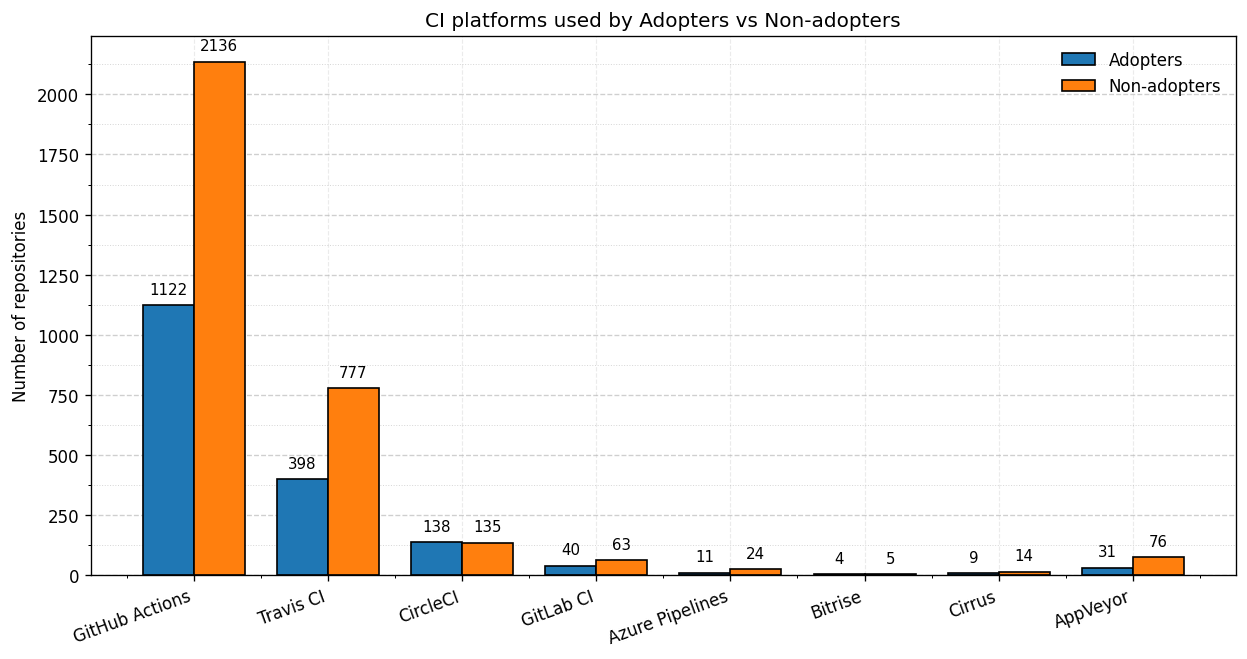

In [3]:
# -*- coding: utf-8 -*-
"""
CI Platform comparison for Adopters vs Non-adopters

What this does
--------------
- Uses 'Adopters' to split the dataset into two cohorts.
- Detects CI providers by scanning column names for provider tokens.
- Counts #repos using each provider within each cohort.
- Outputs:
    * RQ1_F4_provider_by_adoption.csv
      Columns: Provider, Adopters_n, Nonadopters_n, Adopters_share(%), Nonadopters_share(%), Combined_total
    * RQ1_F4_provider_by_adoption_grouped.png  (grouped bar chart)

Assumptions
-----------
- Main file: 5.0_Total_Repo.csv in BASE_DIR
- Column 'Adopters' exists (bool/int/str convertible to 0/1).
- Provider presence is indicated by one or more columns whose NAMES contain provider tokens
  (e.g., 'github_actions', 'gha_yml_files', 'travis_config_present', etc.).

If you also keep a single "provider list" column, we can merge that later—just tell me its name.
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# ==================== CONFIG ====================
BASE_DIR  = Path(r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\1_Main_Spreadsheet")
CSV_PATH  = BASE_DIR / "5.0_Total_Repo.csv"   # change if needed

# Outputs
OUT_TABLE = BASE_DIR / "RQ1_F4_provider_by_adoption.csv"
OUT_PNG   = BASE_DIR / "RQ1_F4_provider_by_adoption_grouped.png"

# Provider name -> list of regexes (matched against COLUMN NAMES, case-insensitive)
PROVIDER_PATTERNS = {
    "GitHub Actions": [r"github[_\-\s]?actions?", r"\bgha\b", r"\bgh_actions\b"],
    "Travis CI":      [r"travis"],
    "CircleCI":       [r"circle[_\-\s]?ci", r"\bcircle\b"],
    "GitLab CI":      [r"gitlab[_\-\s]?ci", r"\bgitlab\b"],
    "Azure Pipelines":[r"azure[_\-\s]?(pipelines?|devops)", r"\bazp\b"],
    "Bitrise":        [r"bitrise"],
    "Cirrus":         [r"cirrus"],
    "AppVeyor":       [r"appveyor"],
}
DISPLAY_ORDER = ["GitHub Actions", "Travis CI", "CircleCI", "GitLab CI", "Azure Pipelines", "Bitrise", "Cirrus", "AppVeyor"]
# =================================================

# ---------- helpers ----------
def to01(x) -> int:
    """Coerce heterogeneous flags to 0/1."""
    if pd.isna(x):
        return 0
    s = str(x).strip().lower()
    if s in {"1","true","t","yes","y","on","present"}:
        return 1
    try:
        return int(float(s) > 0)
    except Exception:
        return 0

def find_provider_columns(df: pd.DataFrame) -> dict[str, list[str]]:
    """
    Return mapping: Provider -> [matching column names].
    Scans ALL columns and keeps any whose name matches one of the provider regexes.
    """
    lowermap = {c.lower(): c for c in df.columns}
    found = {}
    for provider, pats in PROVIDER_PATTERNS.items():
        cols = []
        for lc, orig in lowermap.items():
            if any(re.search(p, lc, flags=re.I) for p in pats):
                cols.append(orig)
        found[provider] = cols
    return found

def truthy_series(df_in: pd.DataFrame, cols: list[str]) -> pd.Series:
    """
    For a given provider, mark repo True if ANY of its matching columns are "truthy".
    Works for 0/1, bools, strings like 'true', counts > 0, etc.
    """
    if not cols:
        return pd.Series(False, index=df_in.index)
    acc = pd.Series(False, index=df_in.index)
    for c in cols:
        acc = acc | (df_in[c].map(to01) > 0)
    return acc

# ---------- load ----------
df = pd.read_csv(CSV_PATH, dtype=str)
print(f"Loaded: {CSV_PATH}")

# ---------- sanity checks ----------
if "Adopters" not in df.columns:
    raise KeyError(f"Missing required column 'Adopters'. Available: {list(df.columns)}")

# ---------- cohorts ----------
adopters_mask     = df["Adopters"].map(to01) == 1
nonadopters_mask  = ~adopters_mask
df["_is_adopter"] = adopters_mask

# ---------- provider columns ----------
provider_cols = find_provider_columns(df)

# ---------- counts by cohort ----------
rows = []
n_adopters    = int(adopters_mask.sum())
n_nonadopters = int(nonadopters_mask.sum())
print(f"Adopters / Non-adopters: {n_adopters} / {n_nonadopters}")

for provider in DISPLAY_ORDER:
    cols = provider_cols.get(provider, [])
    # repo uses provider if ANY matching cols are truthy
    uses_provider = truthy_series(df, cols)

    adopters_n    = int((uses_provider & adopters_mask).sum())
    nonadopters_n = int((uses_provider & nonadopters_mask).sum())
    total_n       = adopters_n + nonadopters_n

    adopters_share    = (adopters_n / n_adopters * 100) if n_adopters else 0.0
    nonadopters_share = (nonadopters_n / n_nonadopters * 100) if n_nonadopters else 0.0

    rows.append({
        "Provider": provider,
        "Adopters (n)": adopters_n,
        "Non-adopters (n)": nonadopters_n,
        "Adopters share (%)": round(adopters_share, 1),
        "Non-adopters share (%)": round(nonadopters_share, 1),
        "Combined total (n)": total_n,
    })

table_df = pd.DataFrame(rows)

# ---------- print & save table ----------
print("\n=== CI Platform usage by cohort (Adopters vs Non-adopters) ===\n")
print(table_df.to_string(index=False))

table_df.to_csv(OUT_TABLE, index=False, encoding="utf-8-sig")
print(f"\nSaved table to: {OUT_TABLE}")

# ---------- grouped bar chart ----------
fig, ax = plt.subplots(figsize=(10.5, 5.6), dpi=120)

x = np.arange(len(table_df))
w = 0.38

adopters_vals    = table_df["Adopters (n)"].values
nonadopters_vals = table_df["Non-adopters (n)"].values

bars_a = ax.bar(x - w/2, adopters_vals, width=w, label="Adopters", edgecolor="black")
bars_n = ax.bar(x + w/2, nonadopters_vals, width=w, label="Non-adopters", edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(table_df["Provider"], rotation=20, ha="right")
ax.set_ylabel("Number of repositories")
ax.set_title("CI platforms used by Adopters vs Non-adopters")
ax.legend(frameon=False)

# Y-grid with minor ticks
ax.set_axisbelow(True)
ax.yaxis.set_minor_locator(AutoMinorLocator(n=2))
ax.grid(True, which="major", axis="y", linestyle="--", linewidth=0.8, alpha=0.6)
ax.grid(True, which="minor", axis="y", linestyle=":",  linewidth=0.6, alpha=0.5)

# Light vertical grid at group centers
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(AutoMinorLocator(n=2))
ax.grid(True, which="major", axis="x", linestyle="--", linewidth=0.7, alpha=0.25)

# Annotate bar heights
def annotate_bars(bars):
    for b in bars:
        h = b.get_height()
        ax.annotate(f"{int(h)}",
                    xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

annotate_bars(bars_a)
annotate_bars(bars_n)

fig.tight_layout()
fig.savefig(OUT_PNG, bbox_inches="tight")
print(f"Saved grouped bar chart to: {OUT_PNG}")

plt.show()
